# Replikasi Eksperimen Giudici et al. (2020)
## *Network Models to Improve Automated Cryptocurrency Portfolio Management*

Notebook ini membandingkan empat strategi portofolio:
1. **Equally Weighted (EW)** — Portofolio naif 1/N
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** — Markowitz + Graphical Lasso
4. **Network Markowitz (NW)** — Integrasi RMT + MST + Centrality Penalty

---
## Sel 1 — Persiapan Library

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada 10 aset kripto utama periode **14 September 2017 – 17 Oktober 2019**.

In [13]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded  : {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period       : {df_returns.index[0].date()} to {df_returns.index[-1].date()}")
print(f"Assets       : {crypto_names}")
df_returns.head()

Data loaded  : 763 days, 10 assets
Period       : 2017-09-15 to 2019-10-17
Assets       : ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


,BTC,ETH,XRP,USDT,BCH,LTC,BNB,EOS,XLM,TRX
Date,,,,,,,,,,
2017-09-15,0.142330,0.0,0.0,0.0,0.0,0.147883,0.0,0.0,0.0,0.0
2017-09-16,-0.003437,0.0,0.0,0.0,0.0,0.000947,0.0,0.0,0.0,0.0
2017-09-17,-0.011698,0.0,0.0,0.0,0.0,0.004794,0.0,0.0,0.0,0.0
2017-09-18,0.126296,0.0,0.0,0.0,0.0,0.135479,0.0,0.0,0.0,0.0
2017-09-19,-0.035104,0.0,0.0,0.0,0.0,-0.049661,0.0,0.0,0.0,0.0


---
## Sel 3 — Statistik Ringkasan (Table 1)

In [14]:
summary_stats = pd.DataFrame({
    'Mean'    : df_returns.mean(),
    'Std'     : df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary Statistics")
print("=" * 55)
print(summary_stats.round(4).to_string())

TABLE 1 | Summary Statistics
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Harga Ternormalisasi (Figure 1 & 2)

Harga awal setiap aset dinormalisasi ke nilai 100.

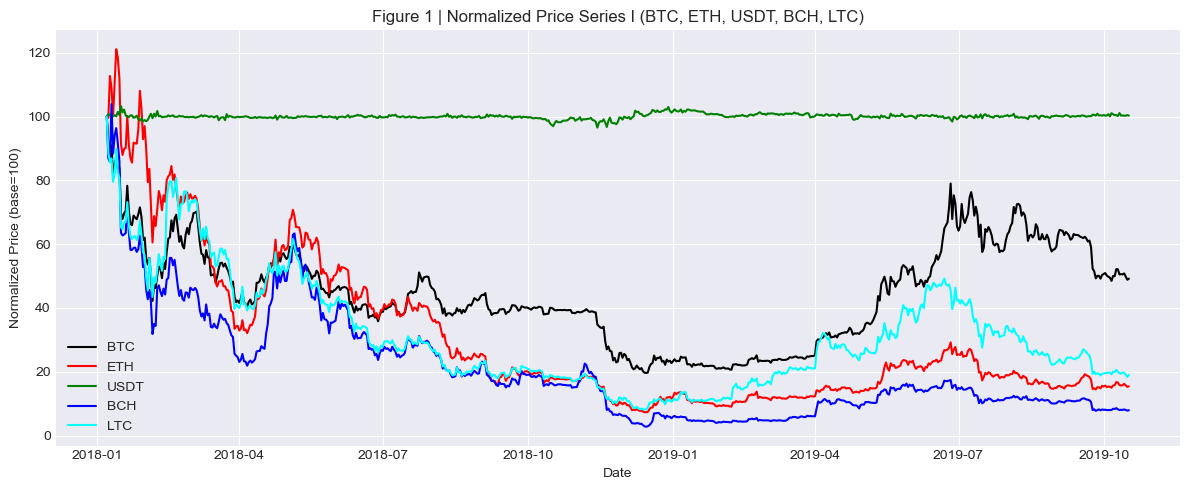

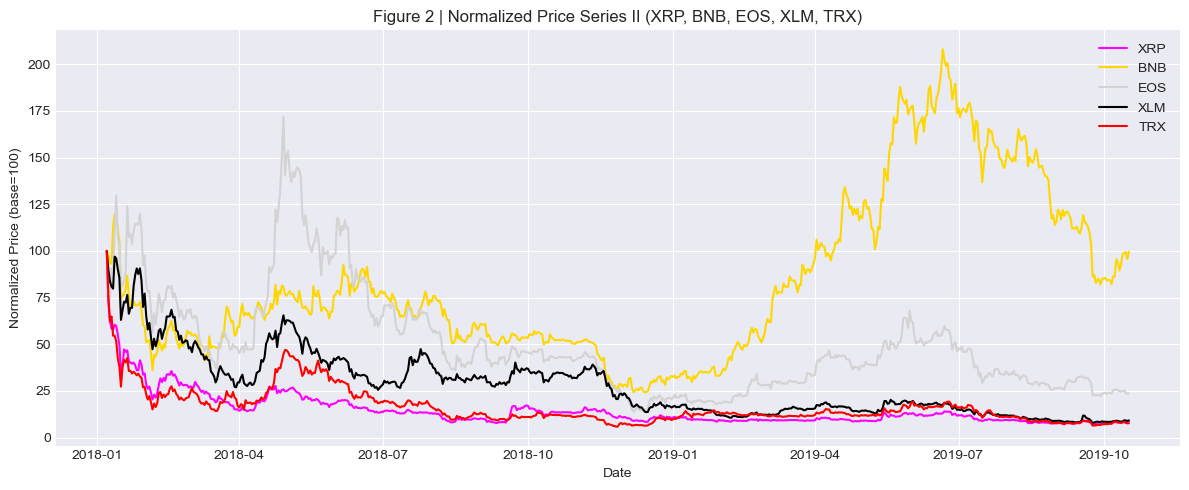

In [15]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

plt.figure(figsize=(12, 5))
colors_1 = ['black', 'red', 'green', 'blue', 'cyan']
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.xlabel('Date'); plt.ylabel('Normalized Price (base=100)')
plt.legend(); plt.tight_layout(); plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

plt.figure(figsize=(12, 5))
colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.xlabel('Date'); plt.ylabel('Normalized Price (base=100)')
plt.legend(); plt.tight_layout(); plt.show()

---
## Sel 5 — Minimum Spanning Tree (Figure 3 & 4)

MST dibangun dari **matriks jarak** $d_{ij} = \sqrt{2(1 - \rho_{ij})}$ untuk dua sub-periode: gelembung spekulatif dan periode stabil.

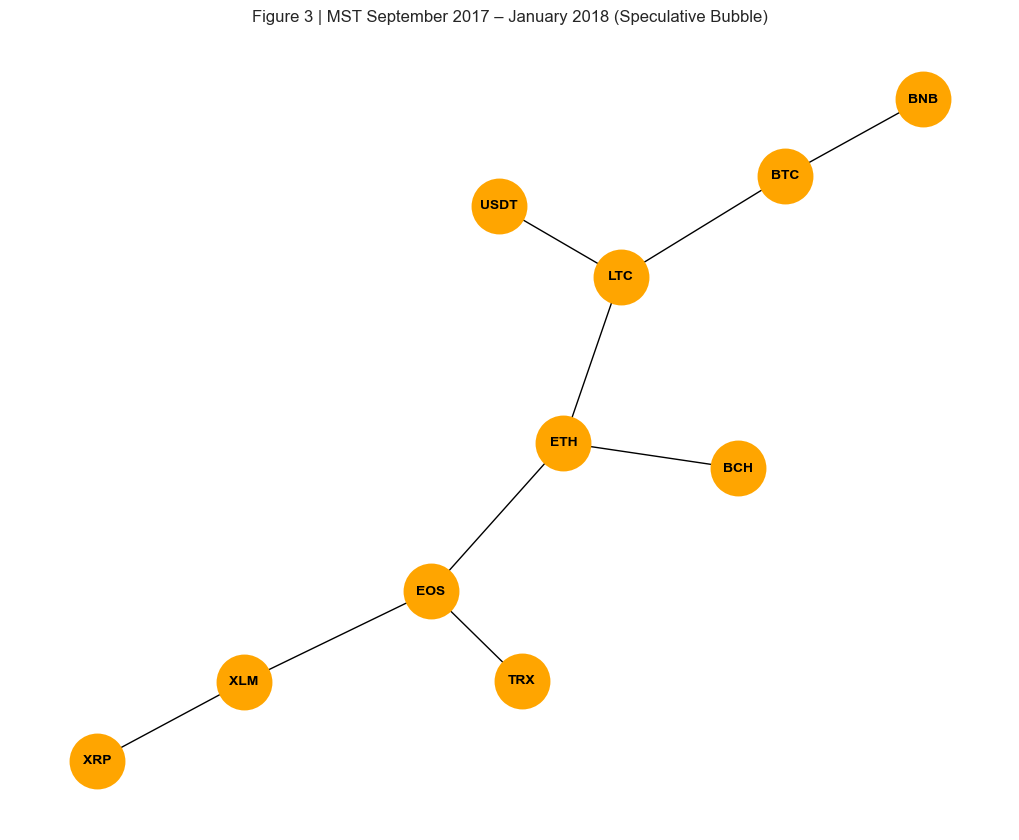

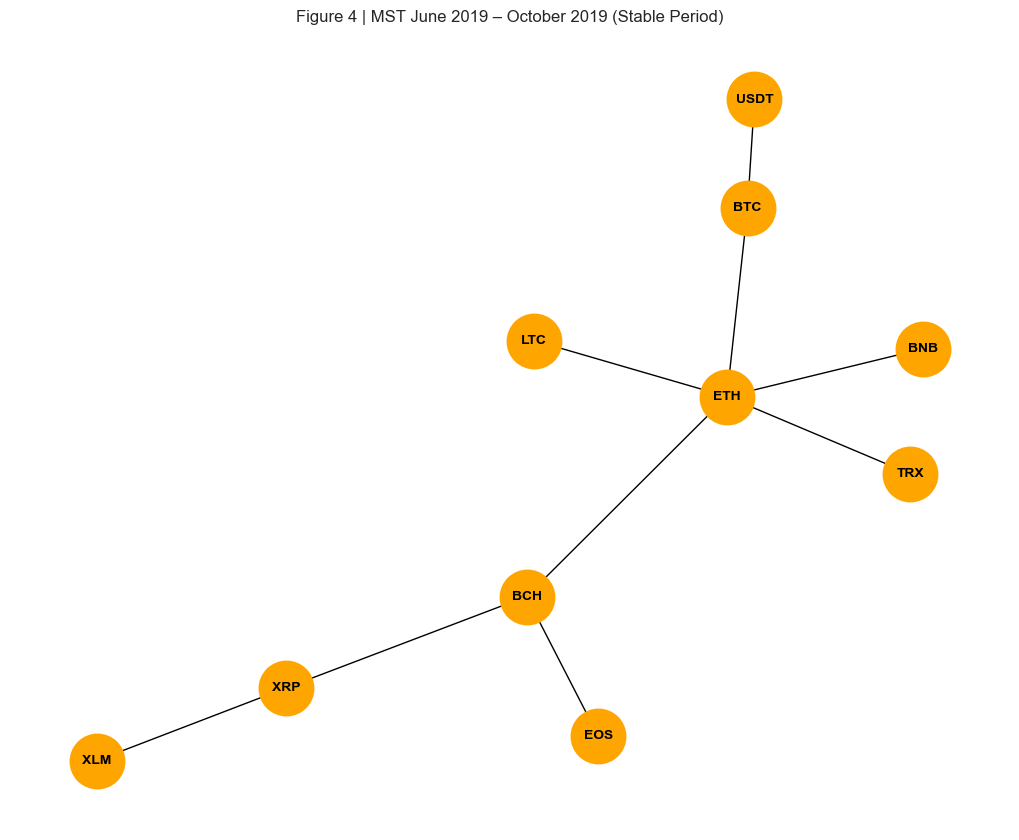

In [16]:
def plot_mst(df_ret, start, end, title, seed=42):
    corr = df_ret.loc[start:end].corr()
    dist = np.sqrt(2 * (1 - corr))
    G    = nx.from_pandas_adjacency(dist)
    mst  = nx.minimum_spanning_tree(G, weight='weight')

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(mst, seed=seed)
    nx.draw(mst, pos, with_labels=True,
            node_color='orange', node_size=1500,
            edge_color='black', linewidths=1.5,
            font_size=10, font_weight='bold')
    plt.title(title, fontsize=12)
    plt.tight_layout(); plt.show()

# Figure 3 — Speculative Bubble
plot_mst(df_returns, '2017-09-14', '2018-01-31',
         'Figure 3 | MST September 2017 – January 2018 (Speculative Bubble)')

# Figure 4 — Stable Period
plot_mst(df_returns, '2019-06-01', '2019-10-17',
         'Figure 4 | MST June 2019 – October 2019 (Stable Period)')

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Mencakup: **RMT Filter**, **MST Builder**, **Eigenvector Centrality**, **VaR**, **Rachev Ratio**, **Max Drawdown**.

In [17]:
# ── RMT Filter ────────────────────────────────────────────────────────────────
def apply_rmt_filter(returns_data):
    """Saring noise pada matriks korelasi menggunakan Random Matrix Theory."""
    if isinstance(returns_data, pd.DataFrame):
        returns_data = returns_data.values
    T, N = returns_data.shape
    Q    = T / N
    C    = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    lambda_plus       = 1 + (1/Q) + 2*np.sqrt(1/Q)   # Marchenko-Pastur upper bound
    significant_mask  = eigenvalues > lambda_plus
    Lambda_filtered   = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered        = eigenvectors @ Lambda_filtered @ eigenvectors.T
    # Pastikan diagonal = 1
    np.fill_diagonal(C_filtered, 1.0)
    return C_filtered

# ── MST Builder ───────────────────────────────────────────────────────────────
def build_mst(correlation_matrix):
    """Ubah matriks korelasi menjadi matriks jarak MST."""
    distance_matrix = np.sqrt(np.clip(2 - 2*correlation_matrix, 0, None))
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

# ── Eigenvector Centrality ────────────────────────────────────────────────────
def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    _, eigenvectors         = eigh(adjacency)
    principal_eigenvector   = np.abs(eigenvectors[:, -1])
    centrality              = principal_eigenvector / principal_eigenvector.sum()
    return centrality

# ── Risk Metrics ──────────────────────────────────────────────────────────────
def calculate_var(returns, confidence=0.95):
    """Value at Risk (VaR) historis."""
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio: CVaR atas / CVaR bawah."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper      = returns[returns >= threshold_upper].mean()
    cvar_lower      = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Maximum Drawdown dari seri cumulative returns."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()

print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Rolling window untuk menghitung **max link distance** dan **residuality** MST sepanjang waktu.

Calculating rolling MST metrics (this may take a moment)...


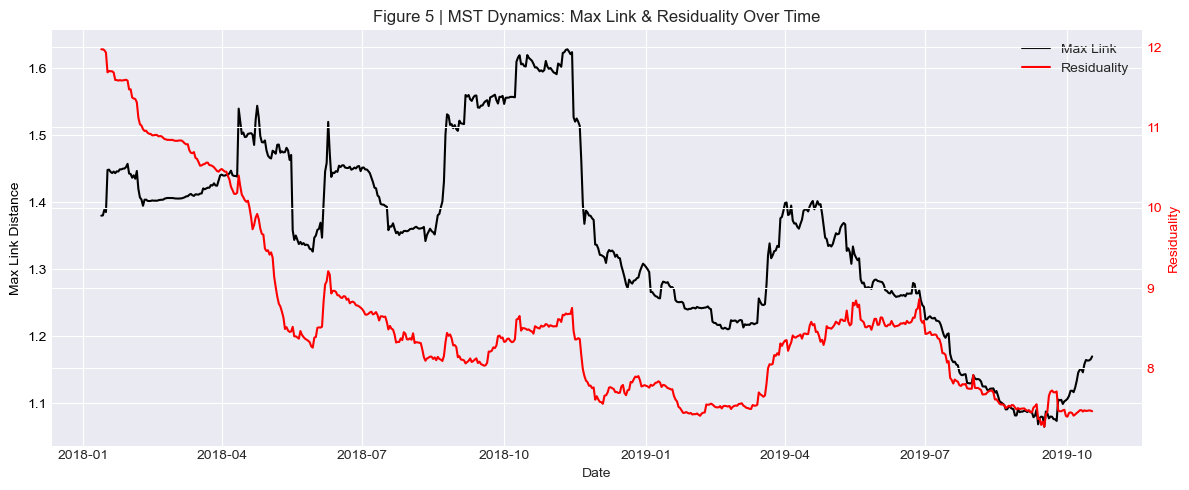

In [18]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []
    N = returns_df.shape[1]

    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i-window:i].values
        corr_f      = apply_rmt_filter(window_data)
        dist        = build_mst(corr_f)
        max_links.append(np.max(dist))
        residualities.append(np.sum(dist) / (N - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

print("Calculating rolling MST metrics (this may take a moment)...")
mst_dyn = calculate_rolling_mst_metrics(df_returns)

# --- Dual-axis plot ---
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.set_xlabel('Date'); ax1.set_ylabel('Max Link Distance', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality Over Time')
plt.tight_layout(); plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi mewarisi kelas `PortfolioStrategy`. **Network Markowitz** menggunakan penalti sentralitas $\gamma \sum_i c_i w_i$.

In [19]:
# ── Base Class ────────────────────────────────────────────────────────────────
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError

# ── 1. Equally Weighted ───────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

# ── 2. Classical Markowitz ────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        S  = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n)/n, method='SLSQP',
                       bounds=[(0, 1)]*n, constraints=constraints)
        return res.x if res.success else np.ones(n)/n

# ── 3. Glasso Markowitz ───────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV(cv=5)
            glasso.fit(returns_data)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n)/n, method='SLSQP',
                       bounds=[(0, 1)]*n, constraints=constraints)
        return res.x if res.success else np.ones(n)/n

# ── 4. Network Markowitz ──────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values

        Cf   = apply_rmt_filter(returns_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf

        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n)/n, method='SLSQP',
                       bounds=[(0, 1)]*n, constraints=constraints)
        return res.x if res.success else np.ones(n)/n

print("Strategy classes defined successfully!")

Strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Rolling window **120 hari**, rebalancing setiap **7 hari**, biaya transaksi **0.1%** (10 bps).

In [20]:
def backtest_strategy(strategy, df_returns, window_size=120,
                      rebalance_freq=7, transaction_cost=0.001):
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train = df_returns.iloc[i - window_size:i]
        w     = strategy.get_weights(train)

        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost    # biaya rebalancing
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy'          : strategy.name,
        'returns'           : np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df'        : res_df
    }

print("Backtest function ready!")

Backtest function ready!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan semua strategi secara berurutan.

In [21]:
# --- Tambahkan ini di Sel 9 ---

# Inisialisasi semua strategi
strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW", gamma=0),
    NetworkMarkowitz("gamma=0.005", gamma=0.005),
    NetworkMarkowitz("gamma=0.025", gamma=0.025),
    NetworkMarkowitz("gamma=0.05",  gamma=0.05),
    NetworkMarkowitz("gamma=0.15",  gamma=0.15),
    NetworkMarkowitz("gamma=0.7",   gamma=0.7),
    NetworkMarkowitz("gamma=1.0",   gamma=1.0),
]

# Jalankan backtest
results = {}

# --- PERBAIKAN DI SINI: Tambahkan 'returns' dan 'cumulative_returns' ---
crix_returns_series = df_returns['BTC'].iloc[120:]
c_returns_vals = crix_returns_series.values
c_cum_vals = (1 + crix_returns_series).cumprod().values

results['CRIX'] = {
    'strategy': 'CRIX',
    'returns': c_returns_vals,                    # <--- Tambahan agar metrik tidak error
    'cumulative_returns': c_cum_vals,             # <--- Tambahan agar metrik tidak error
    'results_df': pd.DataFrame({
        'date': crix_returns_series.index,
        'return': c_returns_vals,
        'cumulative_return': c_cum_vals
    })
}

for s in strategies:
    print(f"  Testing: {s.name}...")
    results[s.name] = backtest_strategy(s, df_returns)

print("\nBacktest selesai. Sekarang Anda bisa jalankan Sel 10 dan 11.")


  Testing: EW...
  Testing: CM...
  Testing: GM...
  Testing: NW...
  Testing: gamma=0.005...
  Testing: gamma=0.025...
  Testing: gamma=0.05...
  Testing: gamma=0.15...
  Testing: gamma=0.7...
  Testing: gamma=1.0...

Backtest selesai. Sekarang Anda bisa jalankan Sel 10 dan 11.


---
## Sel 10 — Kalkulasi Metrik Performa (Table 2)

In [22]:
def calculate_metrics(result):
    r  = result['returns']
    cr = result['cumulative_returns']

    ann_ret = np.mean(r) * 252
    ann_vol = np.std(r) * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0

    return {
        'Strategy'          : result['strategy'],
        'Total Return (%)'  : round((cr[-1] - 1) * 100, 2),
        'Ann. Return (%)'   : round(ann_ret * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio'      : round(sharpe, 4),
        'Max Drawdown (%)'  : round(calculate_max_drawdown(cr) * 100, 2),
        'VaR 95% (%)'       : round(calculate_var(r) * 100, 4),
        'Rachev Ratio'      : round(calculate_rachev_ratio(r), 4)
    }

metrics_df = pd.DataFrame([calculate_metrics(res) for res in results.values()])
metrics_df = metrics_df.set_index('Strategy')

print("TABLE 2 | Performance Metrics Comparison")
print("=" * 90)
print(metrics_df.to_string())

TABLE 2 | Performance Metrics Comparison
             Total Return (%)  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  VaR 95% (%)  Rachev Ratio
Strategy                                                                                                                      
CRIX                   -65.29           -21.37                62.87       -0.3400            -83.33      -6.6094        0.8871
EW                     -88.49           -59.93                69.31       -0.8646            -91.45      -7.7519        0.8014
CM                     -61.56           -30.58                36.13       -0.8464            -69.50      -3.6092        0.7734
GM                     -67.05           -35.74                38.36       -0.9317            -74.31      -4.2237        0.7402
NW                     -61.44           -30.67                35.61       -0.8611            -69.42      -3.4832        0.7669
gamma=0.005            -57.36           -27.02                34.79   

In [23]:
print("\nTABLE 2 | Cumulative Profits and Losses (Periodic Comparison)")

# Tentukan tanggal target sesuai gambar (Jan, Mei, Sep)
target_dates = ['2018-01-31', '2018-05-31', '2018-09-30', 
                '2019-01-31', '2019-05-31', '2019-09-30']
target_labels = ['Jan-2018', 'May-2018', 'Sep-2018', 
                 'Jan-2019', 'May-2019', 'Sep-2019']

periodic_data = []

for d_str, label in zip(target_dates, target_labels):
    row = {'Period': label}
    dt = pd.to_datetime(d_str)
    
    for name, res in results.items():
        df_res = res['results_df']
        # Cari data terdekat pada atau sebelum tanggal target
        mask = df_res['date'] <= dt
        if not mask.any():
            row[name] = "-"
        else:
            # Hitung Profit/Loss Kumulatif (%)
            last_cum = df_res.loc[mask, 'cumulative_return'].iloc[-1]
            row[name] = f"{((last_cum - 1) * 100):.2f}"
    
    periodic_data.append(row)

table_2_df = pd.DataFrame(periodic_data)

# Urutkan kolom agar persis seperti gambar
# Catatan: Sesuaikan nama kolom jika ada perbedaan penulisan
cols_order = ['Period', 'CRIX', 'GM', 'EW', 'CM', 'NW', 
              'gamma=0.005', 'gamma=0.025', 'gamma=0.05', 
              'gamma=0.15', 'gamma=0.7', 'gamma=1.0']
              
# Filter hanya kolom yang benar-benar ada
available_cols = [c for c in cols_order if c in table_2_df.columns]
table_2_df = table_2_df[available_cols]

print("=" * 115)
print(table_2_df.to_string(index=False))
print("-" * 115)
print("Note: Values represent cumulative percentage returns since start of period.")



TABLE 2 | Cumulative Profits and Losses (Periodic Comparison)
  Period   CRIX     GM     EW     CM     NW gamma=0.005 gamma=0.025 gamma=0.05 gamma=0.15 gamma=0.7 gamma=1.0
Jan-2018 -30.04 -33.86 -35.53 -34.32 -32.23      -32.43      -33.61     -33.95     -34.85    -38.46    -40.16
May-2018 -55.73 -60.11 -58.96 -57.88 -58.52      -58.12      -58.19     -57.77     -58.01    -56.67    -56.36
Sep-2018 -62.99 -61.90 -77.02 -59.66 -59.95      -59.40      -60.28     -59.46     -59.44    -58.05    -57.87
Jan-2019 -82.24 -73.12 -89.67 -68.22 -68.17      -63.87      -60.79     -59.98     -59.96    -58.59    -58.41
May-2019 -58.62 -62.49 -77.88 -55.67 -56.55      -52.02      -50.20     -48.61     -48.54    -46.77    -46.55
Sep-2019 -64.37 -67.53 -88.82 -62.16 -62.20      -57.74      -55.86     -53.99     -54.10    -53.06    -52.86
-------------------------------------------------------------------------------------------------------------------
Note: Values represent cumulative percentage return

---
## Sel 11 — Visualisasi Cumulative Returns

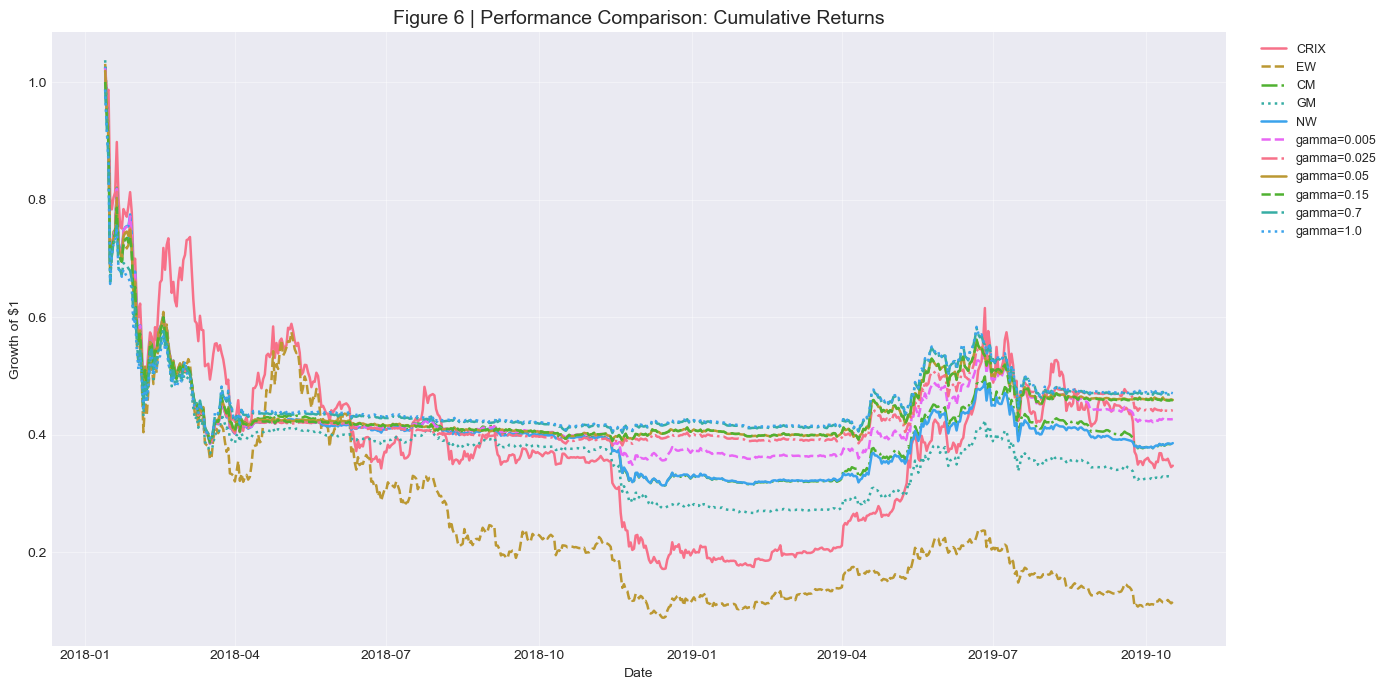

Figure saved as 'cumulative_returns.png'


In [24]:
plt.figure(figsize=(14, 7))

linestyles = ['-', '--', '-.', ':', '-', '--', '-.']
for idx, (name, res) in enumerate(results.items()):
    plt.plot(
        res['results_df']['date'],
        res['cumulative_returns'],
        label=name,
        linestyle=linestyles[idx % len(linestyles)],
        linewidth=1.8
    )

plt.title('Figure 6 | Performance Comparison: Cumulative Returns', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Growth of $1')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'cumulative_returns.png'")